<a href="https://colab.research.google.com/github/aakankshalahane/SQL-Projects-/blob/main/Advanced_Business_Intelligence_Dashboard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Business Intelligence KPIs


,Total_Orders,Total_Sales,Total_Profit,Total_Customers,Average_Order_Value,Profit_Margin
0,20,18200,3640,348,910.0,0.0


Regional Performance


,Region,Total_Sales,Total_Profit,Customers
0,North,5000,1000,89
1,West,4700,940,91
2,East,4500,900,91
3,South,4000,800,77


Category Performance


,Category,Total_Sales,Total_Profit,Customers
0,Furniture,7800,1560,142
1,Electronics,7400,1480,133
2,Clothing,3000,600,73


Top 10 Products


,Product,Category,Sales,Profit
0,Sofa,Furniture,1800,360
1,Phone,Electronics,1500,300
2,Tablet,Electronics,1350,270
3,Monitor,Electronics,1250,250
4,Laptop,Electronics,1200,240
5,Office Chair,Furniture,1200,240
6,Table,Furniture,1100,220
7,Bookshelf,Furniture,1050,210
8,Desk,Furniture,950,190
9,Cabinet,Furniture,900,180


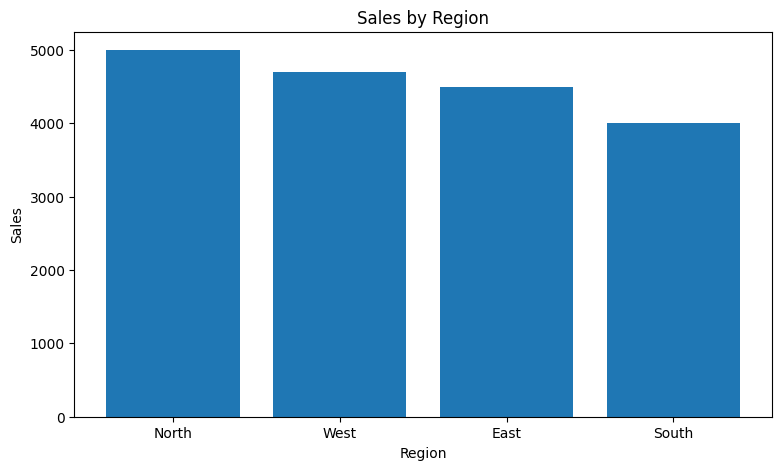

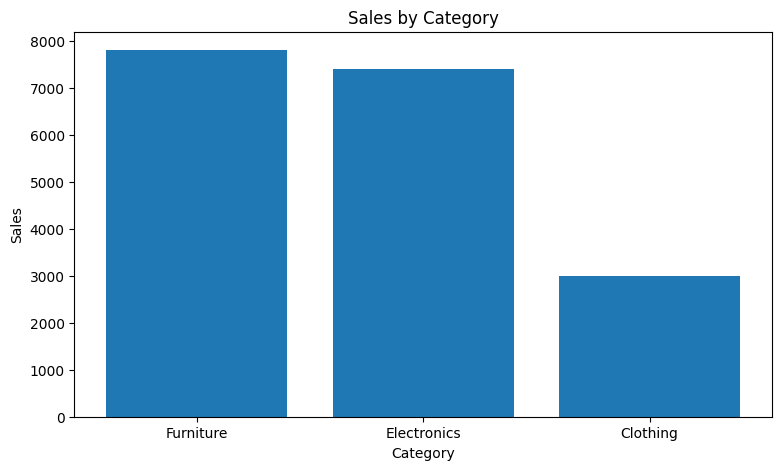

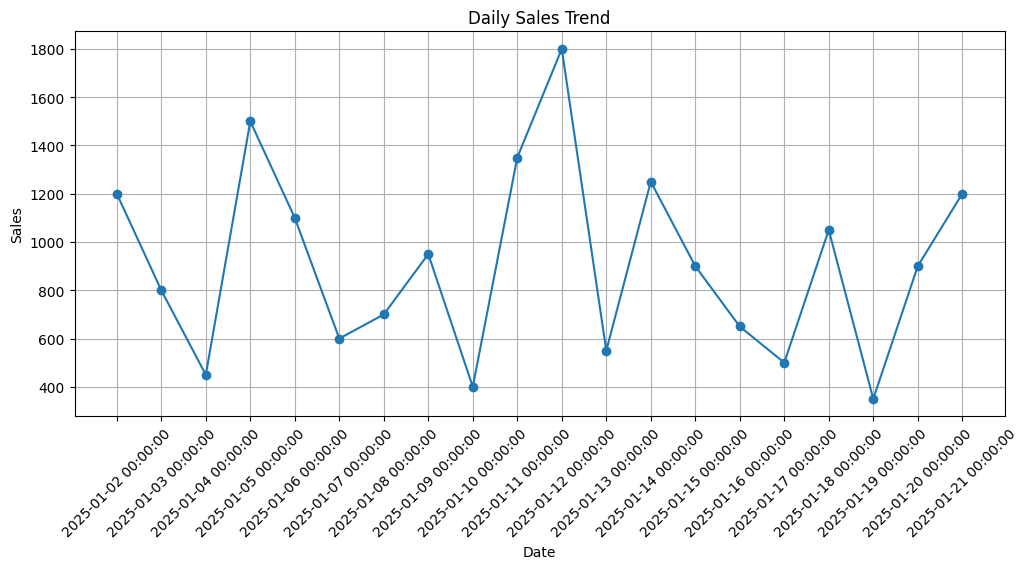

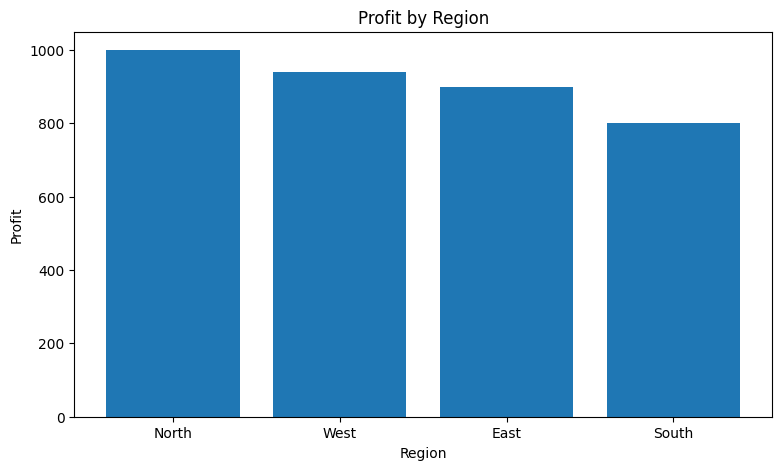

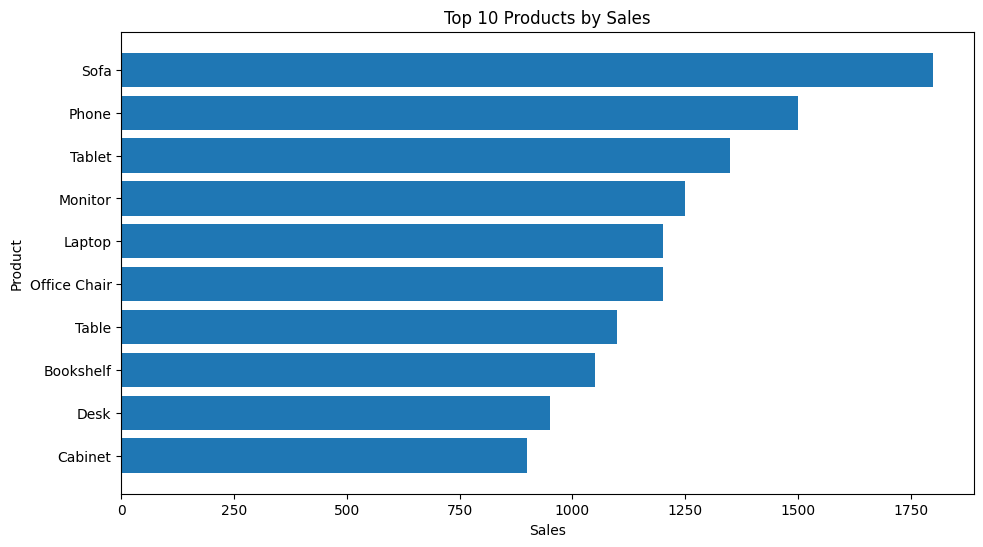

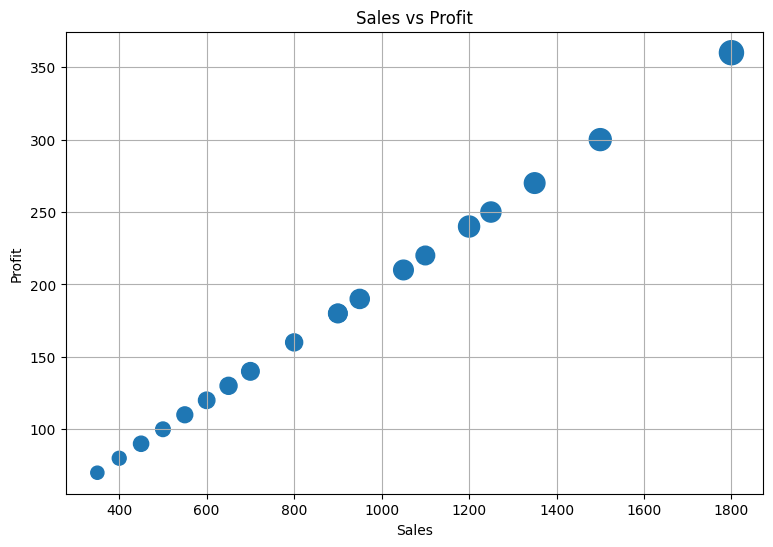

Business Insights
Best performing region: North
Best performing category: Furniture
Top selling product: Sofa
Total sales: ₹18,200.0
Total profit: ₹3,640.0
Profit margin: 0.0%
Advanced Business Intelligence Dashboard completed successfully.


In [ ]:
# Install required libraries
!pip -q install pandas matplotlib

# Import libraries
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Dataset
sales_data = {
    "Order_ID": range(1001, 1021),
    "Date": [
        "2025-01-02","2025-01-03","2025-01-04","2025-01-05","2025-01-06",
        "2025-01-07","2025-01-08","2025-01-09","2025-01-10","2025-01-11",
        "2025-01-12","2025-01-13","2025-01-14","2025-01-15","2025-01-16",
        "2025-01-17","2025-01-18","2025-01-19","2025-01-20","2025-01-21"
    ],
    "Region": [
        "North","South","East","West","North",
        "South","East","West","North","South",
        "East","West","North","South","East",
        "West","North","South","East","West"
    ],
    "Category": [
        "Electronics","Furniture","Clothing","Electronics","Furniture",
        "Clothing","Electronics","Furniture","Clothing","Electronics",
        "Furniture","Clothing","Electronics","Furniture","Clothing",
        "Electronics","Furniture","Clothing","Electronics","Furniture"
    ],
    "Product": [
        "Laptop","Chair","Jacket","Phone","Table",
        "Shoes","Headphones","Desk","Shirt","Tablet",
        "Sofa","Jeans","Monitor","Cabinet","Dress",
        "Keyboard","Bookshelf","T-Shirt","Smartwatch","Office Chair"
    ],
    "Sales": [
        1200,800,450,1500,1100,
        600,700,950,400,1350,
        1800,550,1250,900,650,
        500,1050,350,900,1200
    ],
    "Profit": [
        240,160,90,300,220,
        120,140,190,80,270,
        360,110,250,180,130,
        100,210,70,180,240
    ],
    "Customers": [
        20,15,12,25,18,
        14,16,19,10,22,
        30,13,21,17,15,
        11,20,9,18,23
    ]
}

df = pd.DataFrame(sales_data)

# Convert date
df["Date"] = pd.to_datetime(df["Date"])

# Create database
connection = sqlite3.connect(":memory:")

df.to_sql("sales", connection, index=False, if_exists="replace")

# KPI dashboard
kpis = pd.read_sql_query("""
SELECT
    COUNT(DISTINCT Order_ID) AS Total_Orders,
    SUM(Sales) AS Total_Sales,
    SUM(Profit) AS Total_Profit,
    SUM(Customers) AS Total_Customers,
    ROUND(AVG(Sales), 2) AS Average_Order_Value,
    ROUND((SUM(Profit) / SUM(Sales)) * 100, 2) AS Profit_Margin
FROM sales
""", connection)

print("Business Intelligence KPIs")
display(kpis)

# Regional performance
regional = pd.read_sql_query("""
SELECT
    Region,
    SUM(Sales) AS Total_Sales,
    SUM(Profit) AS Total_Profit,
    SUM(Customers) AS Customers
FROM sales
GROUP BY Region
ORDER BY Total_Sales DESC
""", connection)

print("Regional Performance")
display(regional)

# Category performance
category = pd.read_sql_query("""
SELECT
    Category,
    SUM(Sales) AS Total_Sales,
    SUM(Profit) AS Total_Profit,
    SUM(Customers) AS Customers
FROM sales
GROUP BY Category
ORDER BY Total_Sales DESC
""", connection)

print("Category Performance")
display(category)

# Top products
top_products = pd.read_sql_query("""
SELECT
    Product,
    Category,
    SUM(Sales) AS Sales,
    SUM(Profit) AS Profit
FROM sales
GROUP BY Product, Category
ORDER BY Sales DESC
LIMIT 10
""", connection)

print("Top 10 Products")
display(top_products)

# Daily sales trend
daily_sales = pd.read_sql_query("""
SELECT
    Date,
    SUM(Sales) AS Sales,
    SUM(Profit) AS Profit
FROM sales
GROUP BY Date
ORDER BY Date
""", connection)

# Regional sales chart
plt.figure(figsize=(9, 5))
plt.bar(regional["Region"], regional["Total_Sales"])
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.show()

# Category sales chart
plt.figure(figsize=(9, 5))
plt.bar(category["Category"], category["Total_Sales"])
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

# Daily sales trend
plt.figure(figsize=(12, 5))
plt.plot(
    daily_sales["Date"],
    daily_sales["Sales"],
    marker="o"
)
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.grid()
plt.show()

# Profit by region
plt.figure(figsize=(9, 5))
plt.bar(regional["Region"], regional["Total_Profit"])
plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")
plt.show()

# Top products chart
plt.figure(figsize=(11, 6))
plt.barh(
    top_products["Product"],
    top_products["Sales"]
)
plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product")
plt.gca().invert_yaxis()
plt.show()

# Sales vs Profit
plt.figure(figsize=(9, 6))
plt.scatter(
    df["Sales"],
    df["Profit"],
    s=df["Customers"] * 10
)
plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.grid()
plt.show()

# Business insights
best_region = regional.iloc[0]["Region"]
best_category = category.iloc[0]["Category"]
best_product = top_products.iloc[0]["Product"]

print("Business Insights")
print(f"Best performing region: {best_region}")
print(f"Best performing category: {best_category}")
print(f"Top selling product: {best_product}")
print(f"Total sales: ₹{kpis.iloc[0]['Total_Sales']:,}")
print(f"Total profit: ₹{kpis.iloc[0]['Total_Profit']:,}")
print(f"Profit margin: {kpis.iloc[0]['Profit_Margin']}%")

connection.close()

print("Advanced Business Intelligence Dashboard completed successfully.")